In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import * # mae imported

from statsforecast import StatsForecast
from statsforecast.models import ARIMA

In [11]:
data = pd.read_csv("../../Downloads/iex-dam-0201-0421.csv")
data = data[(data['period_start'] >= '2026-02-01') & (data['period_start'] <= '2026-04-21 23:50')]
data

,period_start,period,purchase_bid,sell_bid,mcv,mcp,final_scheduled_volume
0,2026-02-01 00:00:00,00:00 - 00:15,11446.6,30678.9,6813.10,2430.97,6813.10
1,2026-02-01 00:15:00,00:15 - 00:30,12066.8,32484.0,7292.50,2461.91,7292.50
2,2026-02-01 00:30:00,00:30 - 00:45,12510.9,34476.2,7501.10,2461.75,7501.10
3,2026-02-01 00:45:00,00:45 - 01:00,12502.6,36013.3,7349.00,2461.03,7349.00
4,2026-02-01 01:00:00,01:00 - 01:15,12423.8,36515.8,7466.60,2430.36,7466.60
...,...,...,...,...,...,...,...
7675,2026-04-21 22:45:00,22:45 - 23:00,43050.0,2120.7,1311.78,10000.00,1311.78
7676,2026-04-21 23:00:00,23:00 - 23:15,45429.2,1897.0,1288.20,10000.00,1288.20
7677,2026-04-21 23:15:00,23:15 - 23:30,45725.9,1897.9,1289.10,10000.00,1289.10
7678,2026-04-21 23:30:00,23:30 - 23:45,44030.5,1659.4,1291.99,10000.00,1291.99


In [13]:
data = data.rename(columns={
    'period_start': 'ds',  # Your timestamp
    'purchase_bid': 'y'             # The target value you want to plot (Market Clearing Price)
})
filtered_data = data[[ "ds", "y" ]].copy()
filtered_data['unique_id'] = 'series_1'
filtered_data["ds"] = pd.to_datetime(filtered_data["ds"])

In [17]:
temp_map = {
    '2026-03-12': 39.2, '2026-03-13': 40.8, '2026-03-14': 41.5, '2026-03-15': 39.8,
    '2026-04-17': 43.0, '2026-04-18': 44.2, '2026-04-19': 44.8, '2026-04-20': 45.2,
    '2026-04-21': 44.9
}
filtered_data['date_str'] = filtered_data['ds'].dt.strftime('%Y-%m-%d')
filtered_data['proxy_temp'] = filtered_data['date_str'].map(temp_map).fillna(34.0) 

filtered_data['heat_stress'] = filtered_data['proxy_temp'].apply(lambda x: max(0, x - 40)**2)
filtered_data.drop(columns=["proxy_temp", "date_str"], inplace=True)

In [18]:
horizon = 96*7

data_with_exog = filtered_data.copy()
data_with_exog["weekday_enum"] = data_with_exog["ds"].dt.weekday + 1

test = data_with_exog.groupby("unique_id").tail(horizon)
train = data_with_exog.drop(test.index).reset_index(drop=True)

futr_exog_df = test.drop(["y"], axis=1)
futr_exog_df.head()

,ds,unique_id,heat_stress,weekday_enum
7008,2026-04-15 00:00:00,series_1,0.0,3
7009,2026-04-15 00:15:00,series_1,0.0,3
7010,2026-04-15 00:30:00,series_1,0.0,3
7011,2026-04-15 00:45:00,series_1,0.0,3
7012,2026-04-15 01:00:00,series_1,0.0,3


In [21]:
models = [
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(0, 1, 1), alias="SARIMA (0,1,0,0,1,1,96) exog")
]

sf = StatsForecast(models=models, freq="15min")
sf.fit(df=train)
preds = sf.predict(h=horizon, X_df=futr_exog_df)

test_w_preds = pd.merge(test, preds, 'left', ['ds', 'unique_id'])

In [26]:
# arima_eval = arima_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
metrics = evaluate(
    test_w_preds.drop(columns=["weekday_enum", "heat_stress"]),
    metrics=[mae],
)
metrics

,unique_id,metric,"SARIMA (0,1,0,0,1,1,96) exog"
0,series_1,mae,6136.908613


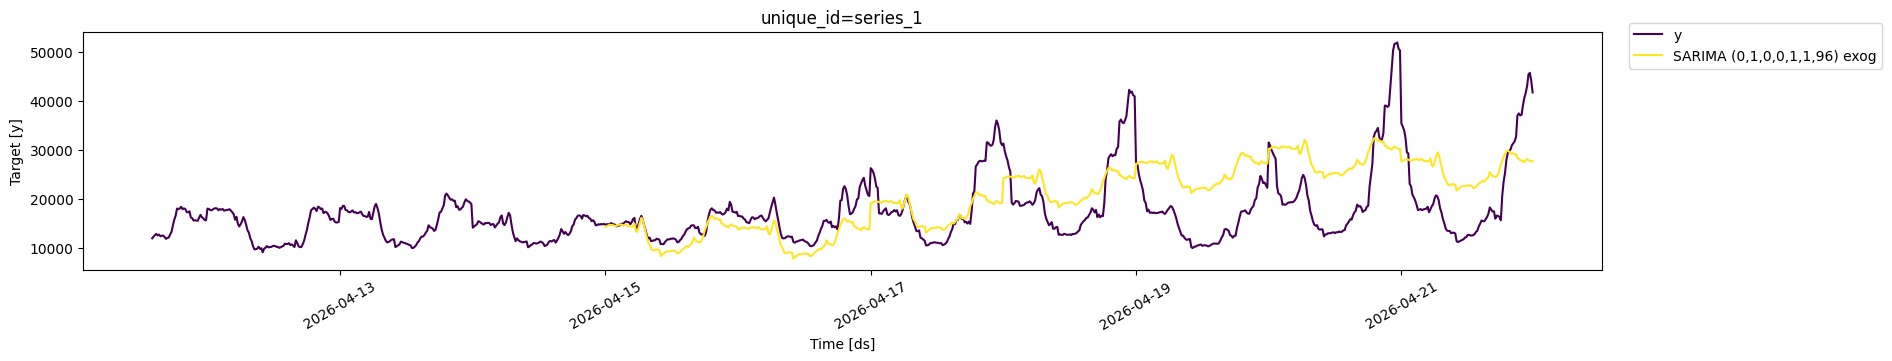

In [27]:
plot_series(
    df=filtered_data, 
    forecasts_df=preds,  
    max_insample_length=1000, 
    palette="viridis")

In [25]:
start_mmdd = preds['ds'].min().strftime('%m%d')
end_mmdd = preds['ds'].max().strftime('%m%d')

# 3. Construct the filename
filename = f"predictions_PB_{start_mmdd}_{end_mmdd}.csv"

# 4. Save to CSV
test_w_preds.drop(columns=["unique_id", "weekday_enum"]).to_csv(filename, index=False)

print(f"File saved successfully as: {filename}")

File saved successfully as: predictions_PB_0415_0421.csv
